In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn import tree
from unicodedata import normalize

In [59]:
datos = pd.read_csv('DataSet_Titanic.csv')
datos.head()

,Sobreviviente,Clase,Genero,Edad,HermEsp,PadHij
0,0,3,0,22.0,1,0
1,1,1,1,38.0,1,0
2,1,3,1,26.0,0,0
3,1,1,1,35.0,1,0
4,0,3,0,35.0,0,0


In [60]:
X = datos.drop('Sobreviviente',axis=1)
y = datos['Sobreviviente']

In [61]:
X.head()

,Clase,Genero,Edad,HermEsp,PadHij
0,3,0,22.0,1,0
1,1,1,38.0,1,0
2,3,1,26.0,0,0
3,1,1,35.0,1,0
4,3,0,35.0,0,0


In [62]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Sobreviviente, dtype: int64

In [63]:
arbol = DecisionTreeClassifier(max_depth=4, random_state=42)


In [64]:
arbol.fit(X,y)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [65]:
pred_y = arbol.predict(X)

In [66]:
print("Precision", accuracy_score(pred_y, y))

Precision 0.8207282913165266


In [67]:
cm =confusion_matrix(y,pred_y)
cm

array([[416,   8],
       [120, 170]], dtype=int64)

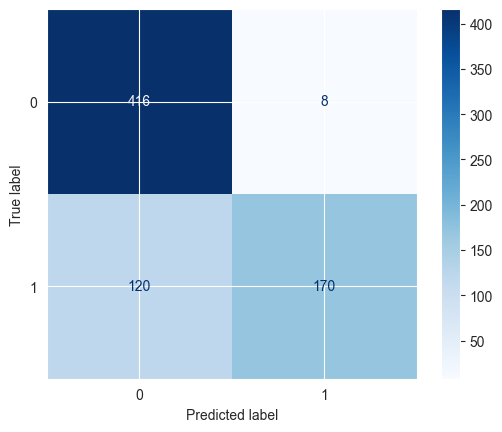

In [68]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, values_format='.0f')
plt.show()


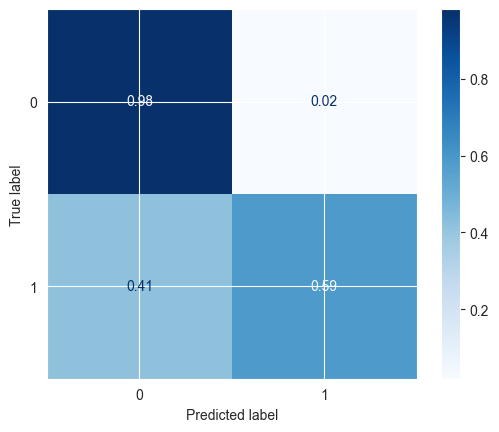

In [69]:
ConfusionMatrixDisplay.from_predictions(
    y_true=y,
    y_pred=arbol.predict(X),
    display_labels=arbol.classes_,
    cmap=plt.cm.Blues,
    normalize='true',
    values_format='.2f'
)
plt.show()


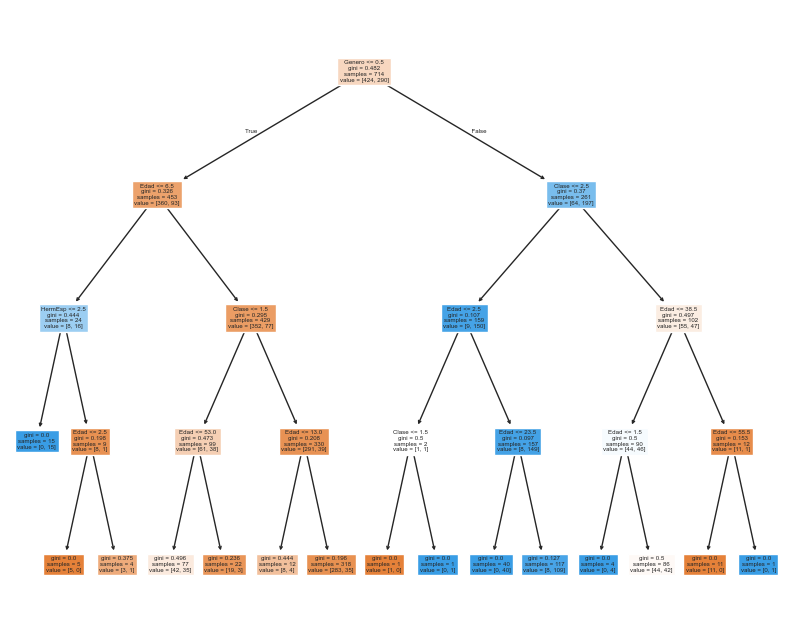

In [70]:
plt.figure(figsize=(10,8))
tree.plot_tree(arbol, filled=True, feature_names=X.columns)
plt.show()


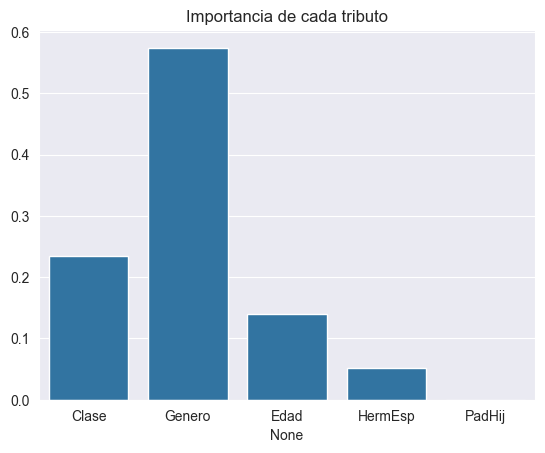

In [72]:
importacias = arbol.feature_importances_
columnas = X.columns

sns.barplot(x=columnas, y=importacias)
plt.title('Importancia de cada tributo')
plt.show()

In [75]:
mi_array = np.array([[[1,2,3],
                      [3,5,8]],
                      [[9,18,2],
                       [5,4,8]]])
mi_array


array([[[ 1,  2,  3],
        [ 3,  5,  8]],

       [[ 9, 18,  2],
        [ 5,  4,  8]]])